Loaded: True
Shape: (744, 744, 3)


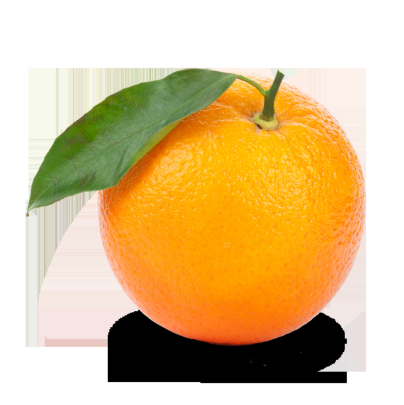

In [2]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("orange.png")
print("Loaded:", img is not None)
print("Shape:", img.shape)

# Remove alpha channel if present
if img.shape[2] == 4:
    img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --------------------------------------------------
# Einstellungen
# --------------------------------------------------
IMG_PATH = "orange.png"          # dein Bild
OUT_DIR  = "cnn_featuremaps"     # Ordner für Output-Bilder
os.makedirs(OUT_DIR, exist_ok=True)

# --------------------------------------------------
# Bild laden & vorbereiten
# --------------------------------------------------
img = cv2.imread(IMG_PATH)
if img is None:
    raise FileNotFoundError(f"Bild nicht gefunden: {IMG_PATH}")

# BGR -> RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Auf 128x128 skalieren (wie in deiner Skizze)
img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_AREA)
h, w, c = img.shape
print("Input:", img.shape)   # (128, 128, 3)

# Für Filterung nehmen wir Graustufen (einfacher zu zeigen)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

def show_and_save(arr, title, filename, cmap="gray"):
    """Hilfsfunktion: normiert, zeigt und speichert Feature-Map."""
    arr_norm = arr.astype(np.float32)
    arr_norm -= arr_norm.min()
    if arr_norm.max() > 0:
        arr_norm /= arr_norm.max()

    plt.figure(figsize=(4,4))
    plt.title(title)
    plt.imshow(arr_norm, cmap=cmap)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, filename), dpi=200)
    plt.close()

# --------------------------------------------------
# Conv1: einfache Kanten-Filter (horizontal & vertikal)
# --------------------------------------------------
# 3x3 Sobel-artige Filter
kernel_edge_x = np.array([[-1, 0, 1],
                          [-2, 0, 2],
                          [-1, 0, 1]], dtype=np.float32)

kernel_edge_y = np.array([[-1,-2,-1],
                          [ 0, 0, 0],
                          [ 1, 2, 1]], dtype=np.float32)

conv1_map1 = cv2.filter2D(gray, -1, kernel_edge_x)  # vertikale Kanten
conv1_map2 = cv2.filter2D(gray, -1, kernel_edge_y)  # horizontale Kanten

print("Conv1 maps:", conv1_map1.shape)  # (128, 128)

show_and_save(gray,        "Input (128×128×1, Graustufen)", "input_gray.png")
show_and_save(conv1_map1,  "Conv1 Map 1 – vertikale Kanten (128×128)", "conv1_map1.png")
show_and_save(conv1_map2,  "Conv1 Map 2 – horizontale Kanten (128×128)", "conv1_map2.png")

# --------------------------------------------------
# Pool1: 2×2 „Pooling“ (wir nehmen einfach Downsampling 128 -> 64)
# --------------------------------------------------
pool1_map1 = cv2.resize(conv1_map1, (64, 64), interpolation=cv2.INTER_AREA)
pool1_map2 = cv2.resize(conv1_map2, (64, 64), interpolation=cv2.INTER_AREA)

print("Pool1 maps:", pool1_map1.shape)  # (64, 64)

show_and_save(pool1_map1, "Pool1 Map 1 (64×64)", "pool1_map1.png")
show_and_save(pool1_map2, "Pool1 Map 2 (64×64)", "pool1_map2.png")

# --------------------------------------------------
# Conv2: etwas „abstraktere“ Filter
#    - Diagonale Kanten
#    - Blob / Textur (Laplacian)
# Wir wenden sie auf die gepoolten Maps an.
# --------------------------------------------------
kernel_diag = np.array([[ 0,-1, 1],
                        [ 1, 0,-1],
                        [-1, 1, 0]], dtype=np.float32)

conv2_map1 = cv2.filter2D(pool1_map1, -1, kernel_diag)          # diagonale Muster
conv2_map2 = cv2.Laplacian(pool1_map2, ddepth=cv2.CV_32F, ksize=3)  # Textur / „Blob“

print("Conv2 maps:", conv2_map1.shape)  # (64, 64)

show_and_save(conv2_map1, "Conv2 Map 1 – diagonale Strukturen (64×64)", "conv2_map1.png")
show_and_save(conv2_map2, "Conv2 Map 2 – Textur/Laplacian (64×64)", "conv2_map2.png")

# --------------------------------------------------
# Pool2: wieder 2×2 „Pooling“ 64 -> 32
# --------------------------------------------------
pool2_map1 = cv2.resize(conv2_map1, (32, 32), interpolation=cv2.INTER_AREA)
pool2_map2 = cv2.resize(conv2_map2, (32, 32), interpolation=cv2.INTER_AREA)

print("Pool2 maps:", pool2_map1.shape)  # (32, 32)

show_and_save(pool2_map1, "Pool2 Map 1 (32×32)", "pool2_map1.png")
show_and_save(pool2_map2, "Pool2 Map 2 (32×32)", "pool2_map2.png")

print(f"Fertig! Bilder liegen im Ordner: {OUT_DIR}")


Input: (128, 128, 3)
Conv1 maps: (128, 128)
Pool1 maps: (64, 64)
Conv2 maps: (64, 64)
Pool2 maps: (32, 32)
Fertig! Bilder liegen im Ordner: cnn_featuremaps
